# 0. Import Packages

In [122]:
# pip install --upgrade scikit-learn numpy

In [123]:
# pip install --upgrade scikit-learn numpy pyarrow

In [124]:
# load and manipulate data and for one hot encoding
import pandas as pd
# calculate mean and sd
import numpy as np

# visualization
import matplotlib.pyplot as plt

# xgboost
import xgboost as xgb

# split data
from sklearn.model_selection import train_test_split
# for scoring
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer
# cross validation
from sklearn.model_selection import GridSearchCV
# confusion matrix
from sklearn.metrics import confusion_matrix
# draw confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay


# 1. Load Data

In [125]:
# read data 
df = pd.read_excel('Telco_customer_churn.xlsx')

In [126]:
# check the data
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [127]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

# 2. Data Cleaning
Last four variables contain exit interview information and shouldn't be used as a prediction, so we remove them.

In [128]:
df.drop(['Churn Label','Churn Score','CLTV','Churn Reason'],
        axis=1, inplace=True) 
        # axis=1 means column inplace=True, modify df directly don't make a copy
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


Some columns only contain single value, so will not be useful for classification.

Customer ID, Lat Long are unnecessary because Lat, Long column exists

In [129]:
df['Count'].unique()

array([1])

In [130]:
df['Country'].unique()

<ArrowStringArray>
['United States']
Length: 1, dtype: str

In [131]:
df['State'].unique()

<ArrowStringArray>
['California']
Length: 1, dtype: str

In [132]:
# city contains lots of city names; so we keep this
df['City'].unique()

<ArrowStringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str

In [133]:
df.drop(['CustomerID','Count','Country','State','Lat Long'],
        axis=1, inplace=True) # inplace=True replaces the actual dataframe 

df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


To draw the tree later on, we need to remove whitespace in the City column.

In [134]:
df['City'] = df['City'].replace(' ','_',regex=True)

In [135]:
# validate the change
df['City'].unique()[0:10]

<ArrowStringArray>
[    'Los_Angeles',   'Beverly_Hills', 'Huntington_Park',         'Lynwood',
  'Marina_Del_Rey',       'Inglewood',    'Santa_Monica',        'Torrance',
        'Whittier',        'La_Habra']
Length: 10, dtype: str

In [136]:
# eliminate white space in column names
df.columns = df.columns.str.replace(' ','_')
df.head()

,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value
0,Los_Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los_Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los_Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los_Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los_Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


## Missing Data

XGBoost has a default behavior for handling missing data. However, we still have to identify missing values and make sure they set to 0. 

If there's already a 0 value, we identify 0 for actual values and for missing values (XGBoost author documentation)

Note, XGBoost only allows int, float, or boolean data types. Therefore, we need to convert object to other types. 

In [137]:
# see data types in each column
df.dtypes

City                     str
Zip_Code               int64
Latitude             float64
Longitude            float64
Gender                   str
Senior_Citizen           str
Partner                  str
Dependents               str
Tenure_Months          int64
Phone_Service            str
Multiple_Lines           str
Internet_Service         str
Online_Security          str
Online_Backup            str
Device_Protection        str
Tech_Support             str
Streaming_TV             str
Streaming_Movies         str
Contract                 str
Paperless_Billing        str
Payment_Method           str
Monthly_Charges      float64
Total_Charges         object
Churn_Value            int64
dtype: object

Total_Charges are numbers, but when trying to convert to numeric, we get an error.
- blank spaces in the column -> indicate missing data

In [138]:
df['Total_Charges'].unique()

array([108.15, 151.65, 820.5, ..., 7362.9, 346.45, 6844.5],
      shape=(6531,), dtype=object)

In [139]:
# see error 
# df['Total_Charges'] = pd.to_numeric(df['Total_Charges'])

In [140]:
# see how many rows are missing data
# loc: get rows where the condition is true
len(df.loc[df['Total_Charges'] == ' '])

11

In [141]:
# look at those 11 rows
df.loc[df['Total_Charges']==' ']

,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value
2234,San_Bernardino,92408,34.084909,-117.258107,Female,No,Yes,No,0,No,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,0
2438,Independence,93526,36.869584,-118.189241,Male,No,No,No,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,0
2568,San_Mateo,94401,37.590421,-122.306467,Female,No,Yes,No,0,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,0
2667,Cupertino,95014,37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,0
2856,Redcrest,95569,40.363446,-123.835041,Female,No,Yes,No,0,No,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,0
4331,Los_Angeles,90029,34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,0
4687,Sun_City,92585,33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,0
5104,Ben_Lomond,95005,37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,0
5719,La_Verne,91750,34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,0
6772,Bell,90201,33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,0


These people's tenure months is 0 because they just subscribed, so they haven't paid anything yet. We can assign total charges to 0.

In [142]:
# replace missing data to 0 for total charges
df.loc[(df['Total_Charges']==' '),'Total_Charges'] = 0 

In [143]:
# verify total charges were set to 0 for those 11 rows
df.loc[df['Tenure_Months']==0]

,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value
2234,San_Bernardino,92408,34.084909,-117.258107,Female,No,Yes,No,0,No,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0,0
2438,Independence,93526,36.869584,-118.189241,Male,No,No,No,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0,0
2568,San_Mateo,94401,37.590421,-122.306467,Female,No,Yes,No,0,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0,0
2667,Cupertino,95014,37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0,0
2856,Redcrest,95569,40.363446,-123.835041,Female,No,Yes,No,0,No,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0,0
4331,Los_Angeles,90029,34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0,0
4687,Sun_City,92585,33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0,0
5104,Ben_Lomond,95005,37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0,0
5719,La_Verne,91750,34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0,0
6772,Bell,90201,33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0,0


In [144]:
# convert data type to numeric

df['Total_Charges'] = pd.to_numeric(df['Total_Charges'])
df.dtypes

City                     str
Zip_Code               int64
Latitude             float64
Longitude            float64
Gender                   str
Senior_Citizen           str
Partner                  str
Dependents               str
Tenure_Months          int64
Phone_Service            str
Multiple_Lines           str
Internet_Service         str
Online_Security          str
Online_Backup            str
Device_Protection        str
Tech_Support             str
Streaming_TV             str
Streaming_Movies         str
Contract                 str
Paperless_Billing        str
Payment_Method           str
Monthly_Charges      float64
Total_Charges        float64
Churn_Value            int64
dtype: object

In [145]:
# replace all blankspace values in df with underscore for printing

df.replace(' ','_',regex=True,inplace=True)
df.head()

,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value
0,Los_Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed_check,53.85,108.15,1
1,Los_Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic_check,70.70,151.65,1
2,Los_Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic_check,99.65,820.50,1
3,Los_Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic_check,104.80,3046.05,1
4,Los_Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank_transfer_(automatic),103.70,5036.30,1


# 3. Feature Engineering

In [146]:
# .copy() ensures original data is not modified 
X = df.drop('Churn_Value',axis=1).copy()
X.head()

,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,...,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges
0,Los_Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed_check,53.85,108.15
1,Los_Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,No,No,No,Month-to-month,Yes,Electronic_check,70.70,151.65
2,Los_Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic_check,99.65,820.50
3,Los_Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic_check,104.80,3046.05
4,Los_Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank_transfer_(automatic),103.70,5036.30


In [147]:
# predicted value is churn
y = df['Churn_Value'].copy()
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Churn_Value, dtype: int64

## One Hot Encoding

Popular Methods of One-Hot Encoding: 
- ColumnTransformer() from scikit-learn
- get_dummies() from pandas

ColumnTransformer is good for handling error but it loses all column names by turning into array.

get_dummies leave data in dataframe and retain column names, but doesn't have persistent behavior.

All columns that are str type, need to be inspected to make sure they contain reasonable values.

XGBoost natively support numerical data like Monthly_Charges and Total_Charges but not categorical data.

In [148]:
# test for one column: see how dummies work
pd.get_dummies(X,columns=['Payment_Method']).head()

,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,...,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Monthly_Charges,Total_Charges,Payment_Method_Bank_transfer_(automatic),Payment_Method_Credit_card_(automatic),Payment_Method_Electronic_check,Payment_Method_Mailed_check
0,Los_Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,Month-to-month,Yes,53.85,108.15,False,False,False,True
1,Los_Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,No,Month-to-month,Yes,70.70,151.65,False,False,True,False
2,Los_Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,Yes,Month-to-month,Yes,99.65,820.50,False,False,True,False
3,Los_Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Yes,Month-to-month,Yes,104.80,3046.05,False,False,True,False
4,Los_Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,Yes,Month-to-month,Yes,103.70,5036.30,True,False,False,False


In [149]:
# encode all these to dummy variables
X_encoded = pd.get_dummies(X, columns = ['City',
                                         'Gender',
                                         'Senior_Citizen',
                                         'Partner',
                                         'Dependents',
                                         'Phone_Service',
                                         'Multiple_Lines',
                                         'Internet_Service',
                                         'Online_Security',
                                         'Online_Backup',
                                         'Device_Protection',
                                         'Tech_Support',
                                         'Streaming_TV',
                                         'Streaming_Movies',
                                         'Contract',
                                         'Paperless_Billing',
                                         'Payment_Method'])

In [150]:
X_encoded.head()

,Zip_Code,Latitude,Longitude,Tenure_Months,Monthly_Charges,Total_Charges,City_Acampo,City_Acton,City_Adelanto,City_Adin,...,Streaming_Movies_Yes,Contract_Month-to-month,Contract_One_year,Contract_Two_year,Paperless_Billing_No,Paperless_Billing_Yes,Payment_Method_Bank_transfer_(automatic),Payment_Method_Credit_card_(automatic),Payment_Method_Electronic_check,Payment_Method_Mailed_check
0,90003,33.964131,-118.272783,2,53.85,108.15,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
1,90005,34.059281,-118.307420,2,70.70,151.65,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
2,90006,34.048013,-118.293953,8,99.65,820.50,False,False,False,False,...,True,True,False,False,False,True,False,False,True,False
3,90010,34.062125,-118.315709,28,104.80,3046.05,False,False,False,False,...,True,True,False,False,False,True,False,False,True,False
4,90015,34.039224,-118.266293,49,103.70,5036.30,False,False,False,False,...,True,True,False,False,False,True,True,False,False,False


In [151]:
# verify y only contains unique values
y.unique()

array([1, 0])

# 4. Model Training

## Split Data to Train and Test Dataset

Churn data is imbalanced, with only 27% people in dataset churning.

To address the imbalance issue, we split data into training and testing using stratification.

Stratification maintains the same percentage of churn in both training and testing set

In [152]:
# number of people that left / total people = 26% left the company
sum(y)/len(y)

0.2653698707936959

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state = 42, stratify = y)

In [154]:
# verify stratify worked as expected
# train 
sum(y_train)/len(y_train)

0.2654297614539947

In [155]:
# test
sum(y_test)/len(y_test)

0.26519023282226006

## Build XGBoost Model

documentation: https://xgboost.readthedocs.io/en/stable/python/callbacks.html


In [ ]:
# tell xgboost what character we're using to represent missing values: treat missing value as npn
# default value when missing like none, np.nan uses 0, so it doesn't allocate memory
# XGBClassifier creates shell
clf_xgb = xgb.XGBClassifier(
        objective='binary:logistic',
        missing=np.nan, 
        early_stopping_rounds=10, # if 10 more trees don't improve predictions, it stops
        eval_metric = 'aucpr', #area under the precision-recall curve
        seed=42)

# create tree by running fit
clf_xgb.fit(X_train,
            y_train,
            verbose=True, # tell what you are doing
            eval_set=[(X_test,y_test)]
            )  

[0]	validation_0-aucpr:0.64484
[1]	validation_0-aucpr:0.65281
[2]	validation_0-aucpr:0.66059
[3]	validation_0-aucpr:0.65424
[4]	validation_0-aucpr:0.66064
[5]	validation_0-aucpr:0.66153
[6]	validation_0-aucpr:0.66547
[7]	validation_0-aucpr:0.66499
[8]	validation_0-aucpr:0.66667
[9]	validation_0-aucpr:0.66309
[10]	validation_0-aucpr:0.66416
[11]	validation_0-aucpr:0.66180
[12]	validation_0-aucpr:0.66855
[13]	validation_0-aucpr:0.66674
[14]	validation_0-aucpr:0.66577
[15]	validation_0-aucpr:0.66509
[16]	validation_0-aucpr:0.66491
[17]	validation_0-aucpr:0.66553
[18]	validation_0-aucpr:0.66463
[19]	validation_0-aucpr:0.66598
[20]	validation_0-aucpr:0.66601
[21]	validation_0-aucpr:0.66762
[22]	validation_0-aucpr:0.66726


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

# 5. Model Evaluation

In [157]:
# make prediction
y_pred = clf_xgb.predict(X_test)

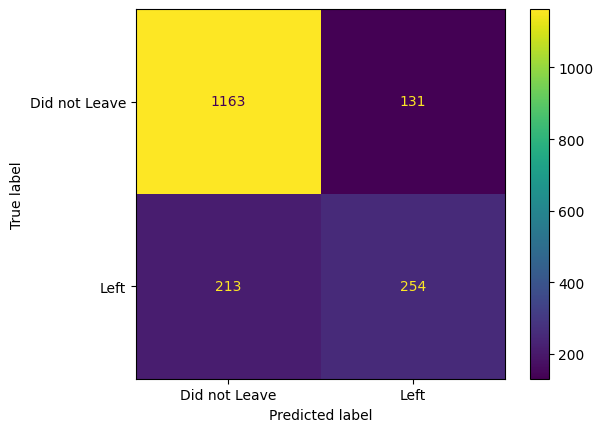

In [158]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Did not Leave","Left"])

disp.plot()
plt.show()

In [178]:
from sklearn.metrics import recall_score

# what % of people who churned were correctly classified as churn? 
sensitivity = recall_score(y_test,y_pred)
print(f"Recall / Sensitivity, recall, TPR: {sensitivity}")

# what % of people who did not churn were correctly identified as not churn?
specificity = 1163/(1163+131) # tn / (tn+fp)
print(f"Specificity: {specificity}")


Recall / Sensitivity, recall, TPR: 0.5438972162740899
Specificity: 0.8987635239567233


## Precision-Recall Curve

Recall measures how many of the actual positive value (churned) were classified as positive (churn)? (tp/tp+fn)
- This metric is useful when false negatives are expensive; missing a churn is more costly than incorrectly identifying as churn
- another example is misclassifying as cancer is less costly than missing a cancer

Precision measures how many of the positive predictions (churned) were actually positive (churned)? (tp/tp+fp)
- This metric is useful when false positives are expensive; incorrectly identifying as churn is more costly than missing a churn
- another example is spam detection, when incorrectly identifying as spam (important email as spam) is more costly than missing a spam

F1 is best for imbalanced data, whereas precision/recall are better for specific penalty-driven use cases



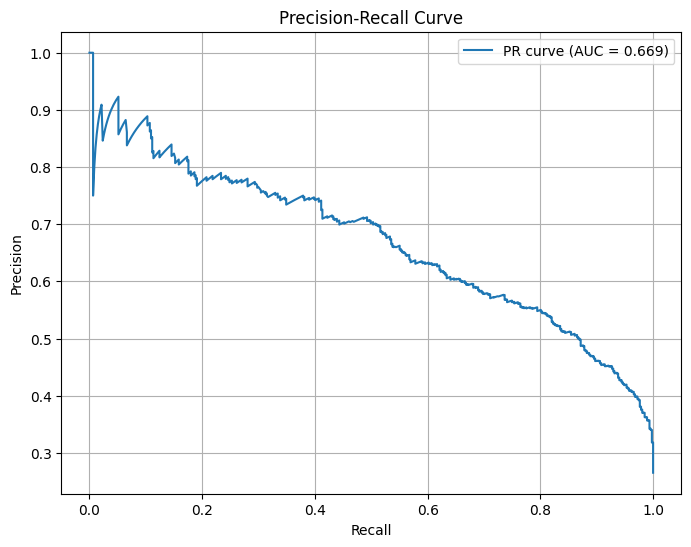

In [177]:
from sklearn.metrics import precision_recall_curve, auc

# predict_proba() returns 2D array: probability of negative class (not churn), probability of positive class(churn)
y_pred_proba = clf_xgb.predict_proba(X_test)[:, 1] # churn prediction probability

precision, recall, thresholds = precision_recall_curve(y_test,y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

For customer churn case, missing a churn customer as not churned is more costly than incorrectly identifying a not churned customer as churn, which means recall is more important than precision. This is because customer leaving a company costs a lot of money, so we want to capture more people that left. 

PR curves are preferred over ROC curves for imbalanced datasets because they exclude True Negatives from calculations, focusing only on the rare positive class.

XGBoost has scale_pos_weight that helps with imbalance data. It adds a penalty for incorrectly classifying the minority class (churn in our case)


## ROC / AUC

What threshold for classifying churn/not churn is the best? ROC provides a simple way to sumarize all confusion matrix that each threshold produced, instead of generating all the confusion matrices. The y axis is the sensitivity / recall, and x axis is 1-specificity, which is also a false positive rate.

The FPR is (fp/fp+tn), which means out of all the cases that were actually negative, how many of the model incorrectly labeled as positive. In other words, how many of the not churned customers were predicted as churn?

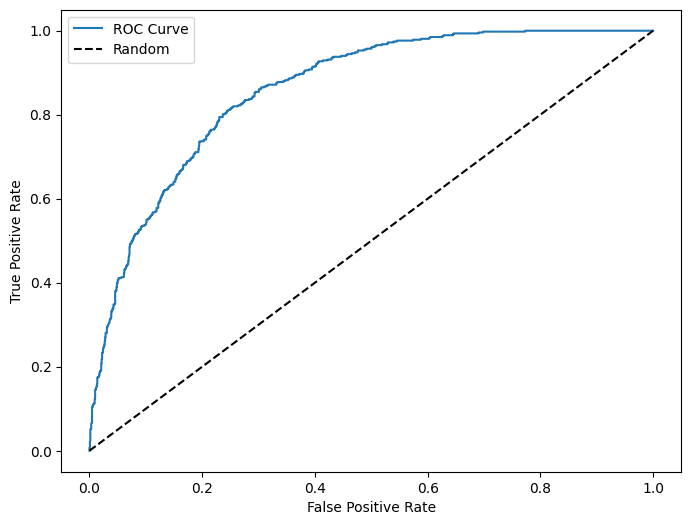

In [ ]:
# what threshold for classifying churn/not churn is the best?
from sklearn.metrics import roc_curve, auc, roc_auc_score

# get roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# plot roc curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,label = f'ROC Curve')
plt.plot([0,1],[0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

The AUC curve makes it easier to compare ROC values across different models.

In [176]:
roc_auc = auc(fpr,tpr)
print(f"AUC: {roc_auc}")


AUC: 0.8588875025235894


Churning costs company a lot of money, so we want to capture more people that left.

XGBoost has scale_pos_weight that helps with imbalance data. It adds a penalty for incorrectly classifying the minority class (churn in our case)

# 6. Optimize Hyperparameters using Cross Validation and GridSearch()

**Manual of XGBoost for Imbalance Data:**
- Use AUC for evaluation
- balance the positive and negative weights via scale_pos_weight
- For scale_pos_weight, XGBoost recommends sum(negative instances) / sum (positive instances)

In [159]:
# round 1 
param_grid = {
    'max_depth': [3,4,5],
    'learning_rate': [0.1,0.01,0.05],
    'gamma':[0,0.25,1.0],
    'reg_lambda':[0,1.0,10.0],
    'scale_pos_weight': [1,3,5]
}

In [160]:
# round 2
param_grid = {
    'max_depth': [4],
    'learning_rate': [0.1,0.5,1],
    'gamma':[0,0.25],
    'reg_lambda':[10.0, 20, 100],
    'scale_pos_weight': [3]
}

In [161]:
# to speed up CV for tree and to prevent overfitting, use subsample, and colsample_bytree 

optimal_params = GridSearchCV(
    estimator = xgb.XGBClassifier(objective='binary:logistic',
                                  seed=42, 
                                  subsample =0.9, # use 90% of the data
                                  colsample_bytree = 0.5 ), # use 50% of the column 
    param_grid = param_grid,
    scoring='roc_auc', # see sckikitlearn modules
    verbose=0,
    n_jobs=10,
    cv = 3 # 3-fold cv
)

In [162]:
optimal_params.fit(X_train,
                   y_train,
                   early_stopping_rounds=10,
                   eval_metric='auc',
                   eval_set=[(X_test,y_test)],
                   verbose=False)

print(optimal_params.best_params_)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/chohasong/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/Users/chohasong/anaconda3/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/chohasong/anaconda3/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, *

ValueError: 
All the 54 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
54 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/chohasong/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/chohasong/anaconda3/lib/python3.11/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'


# Build Final XGBoost Model

In [ ]:
clf_xgb = xgb.XGBClassifier(
        seed=42,
        objective='binary:logistic',
        # new params
        gamma =0.25,
        learn_rate =0.1,
        max_depth = 4,
        reg_lambda = 10,
        scale_pos_weight =3,
        subsample = 0.9,
        colsample_by_tree=0.5,
        early_stopping_rounds=10, # if 10 more trees don't improve predictions, it stops
        eval_metric = 'aucpr'
    )

clf_xgb.fit(X_train,
            y_train,
            verbose=True,
            eval_set=[(X_test,y_test)])

[0]	validation_0-aucpr:0.60485
[1]	validation_0-aucpr:0.61487
[2]	validation_0-aucpr:0.61839
[3]	validation_0-aucpr:0.63447
[4]	validation_0-aucpr:0.63816
[5]	validation_0-aucpr:0.63293
[6]	validation_0-aucpr:0.64624
[7]	validation_0-aucpr:0.64439
[8]	validation_0-aucpr:0.64716


/Users/chohasong/anaconda3/lib/python3.11/site-packages/xgboost/callback.py:385: UserWarning: [18:31:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "colsample_by_tree", "learn_rate" } are not used.

  self.starting_round = model.num_boosted_rounds()


[9]	validation_0-aucpr:0.65182
[10]	validation_0-aucpr:0.65823
[11]	validation_0-aucpr:0.66003
[12]	validation_0-aucpr:0.66413
[13]	validation_0-aucpr:0.66587
[14]	validation_0-aucpr:0.66985
[15]	validation_0-aucpr:0.66541
[16]	validation_0-aucpr:0.66687
[17]	validation_0-aucpr:0.66850
[18]	validation_0-aucpr:0.66874
[19]	validation_0-aucpr:0.66698
[20]	validation_0-aucpr:0.66511
[21]	validation_0-aucpr:0.66256
[22]	validation_0-aucpr:0.66302
[23]	validation_0-aucpr:0.66275
[24]	validation_0-aucpr:0.66215


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
# make prediction
y_pred = clf_xgb.predict(X_test)

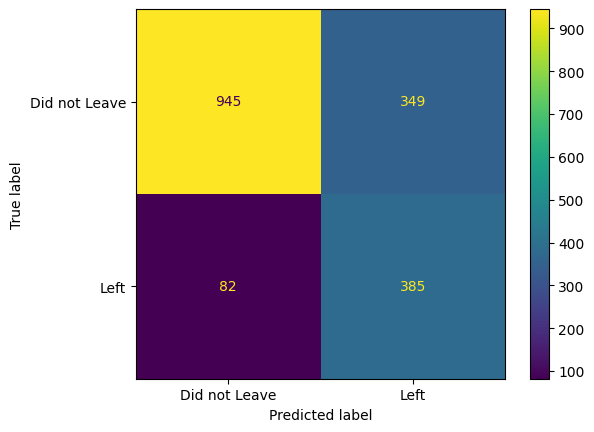

In [ ]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Did not Leave","Left"])

disp.plot()
plt.show()

# Draw Tree

In [ ]:
clf_xgb = xgb.XGBClassifier(
        seed=42,
        objective='binary:logistic',
        # new params
        gamma =0.25,
        learn_rate =0.1,
        max_depth = 4,
        reg_lambda = 10,
        scale_pos_weight =3,
        subsample = 0.9,
        colsample_by_tree=0.5,
        early_stopping_rounds=10, # if 10 more trees don't improve predictions, it stops
        eval_metric = 'aucpr',
        # only build one tree; 
        # to draw first tree to see reasonable values to set for CV for regularization or for hyperparameter turning
        # see gain, weight, cover => gives starting point for optimizing parameters
        n_estimatorrs=1
    )

clf_xgb.fit(X_train,
            y_train,
            verbose=True,
            eval_set=[(X_test,y_test)])

[0]	validation_0-aucpr:0.60485
[1]	validation_0-aucpr:0.61487
[2]	validation_0-aucpr:0.61839
[3]	validation_0-aucpr:0.63447
[4]	validation_0-aucpr:0.63816
[5]	validation_0-aucpr:0.63293
[6]	validation_0-aucpr:0.64624
[7]	validation_0-aucpr:0.64439
[8]	validation_0-aucpr:0.64716
[9]	validation_0-aucpr:0.65182
[10]	validation_0-aucpr:0.65823
[11]	validation_0-aucpr:0.66003
[12]	validation_0-aucpr:0.66413
[13]	validation_0-aucpr:0.66587
[14]	validation_0-aucpr:0.66985
[15]	validation_0-aucpr:0.66541
[16]	validation_0-aucpr:0.66687
[17]	validation_0-aucpr:0.66850
[18]	validation_0-aucpr:0.66874


/Users/chohasong/anaconda3/lib/python3.11/site-packages/xgboost/callback.py:385: UserWarning: [18:34:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "colsample_by_tree", "learn_rate", "n_estimatorrs" } are not used.

  self.starting_round = model.num_boosted_rounds()


[19]	validation_0-aucpr:0.66698
[20]	validation_0-aucpr:0.66511
[21]	validation_0-aucpr:0.66256
[22]	validation_0-aucpr:0.66302
[23]	validation_0-aucpr:0.66275
[24]	validation_0-aucpr:0.66215


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
#!pip install graphviz

  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/91/4c/e0ce1ef95d4000ebc1c11801f9b944fa5910ecc15b5e351865763d8657f8/graphviz-0.21-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.1 MB/s eta 0:00:00


In [ ]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

weight: {'Zip_Code': 34.0, 'Latitude': 24.0, 'Longitude': 20.0, 'Tenure_Months': 45.0, 'Monthly_Charges': 43.0, 'Total_Charges': 28.0, 'City_Bakersfield': 1.0, 'City_Heber': 1.0, 'City_La_Jolla': 1.0, 'City_Running_Springs': 1.0, 'City_Sacramento': 4.0, 'City_San_Bernardino': 2.0, 'City_Santa_Ana': 1.0, 'City_Santa_Barbara': 1.0, 'City_Santa_Clara': 1.0, 'Gender_Female': 3.0, 'Senior_Citizen_No': 3.0, 'Partner_No': 11.0, 'Dependents_No': 21.0, 'Phone_Service_No': 3.0, 'Multiple_Lines_No': 3.0, 'Internet_Service_DSL': 4.0, 'Internet_Service_Fiber_optic': 3.0, 'Online_Security_No': 6.0, 'Online_Security_Yes': 1.0, 'Online_Backup_No': 3.0, 'Online_Backup_Yes': 1.0, 'Device_Protection_No': 5.0, 'Device_Protection_Yes': 1.0, 'Tech_Support_No': 6.0, 'Tech_Support_Yes': 1.0, 'Streaming_TV_Yes': 2.0, 'Streaming_Movies_No': 1.0, 'Streaming_Movies_Yes': 2.0, 'Contract_Month-to-month': 10.0, 'Contract_One_year': 2.0, 'Contract_Two_year': 3.0, 'Paperless_Billing_No': 7.0, 'Payment_Method_Bank_tran

/Users/chohasong/anaconda3/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


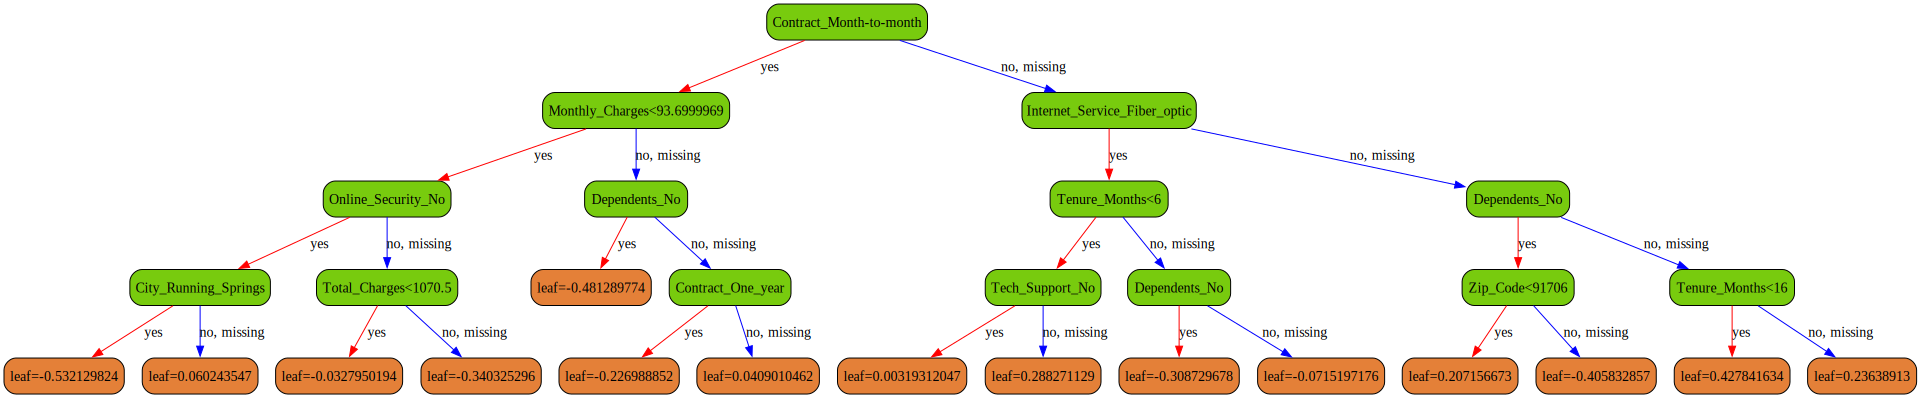

In [ ]:
bst = clf_xgb.get_booster()
# weight = # of times a feature is used in a branch or root across all trees
# gain = average gain across all splits that feature is used in
# cover = average coverage across all splits a feature is used in
# total gain = total gain across all splits feature is used in
# total_cover = total coverage across all splits the feature is used in

for importance_type in ('weight','gain','cover','total_gain','total_cover'):
    print('%s:' % importance_type, bst.get_score(importance_type=importance_type))

node_params = {'shape':'box', #make node fancy
               'style':'filled,rounded',
               'fillcolor':'#78cbe'}

leaf_params = {'shape':'box',
               'style':'filled,rounded',
               'fillcolor':'#e48038'}

# num_tree is the specific tree you want to plot
# default value is 0

xgb.to_graphviz(clf_xgb, num_trees=0, size="10,10",
                condition_node_params = node_params,
                leaf_node_params = leaf_params)